# Regresion Lineal Simple — Precio de viviendas
## El modelo mas simple de ML: una recta que predice precios con R2 > 0,75

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Regresion Lineal Simple

---

### Objetivo

Predecir el precio de viviendas usando **una sola variable** (metros cuadrados) con regresion lineal simple. El objetivo no es solo obtener un modelo — es entender los **supuestos estadisticos** que validan (o invalidan) una regresion lineal y como diagnosticarlos.

### Por que empezar aqui

La regresion lineal simple es el "Hola Mundo" del machine learning supervisado. Si no se entiende una recta, no se entiende nada de lo que viene despues. Este notebook cubre la teoria que muchos portfolios saltan.

## 1. Contexto de negocio

**El cliente:** una inmobiliaria que necesita tasar viviendas rapidamente.

**El problema:** las tasaciones manuales tardan dias. La inmobiliaria quiere un modelo rapido que estime el precio a partir de la superficie, como primer filtro antes de la tasacion formal.

**La pregunta:** por cada metro cuadrado adicional, cuanto sube el precio?

## 2. Stack tecnico

| Libreria | Uso |
|---|---|
| `pandas` | Manipulacion de datos |
| `matplotlib`, `seaborn` | Visualizacion |
| `scikit-learn` | LinearRegression, metricas |
| `scipy.stats` | Test de normalidad (Shapiro-Wilk) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploracion inicial

In [2]:
data = pd.read_excel("datos_regresion_casas.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 100 | Columnas: 4


,Metros_Cuadrados,Distancia_Centro_KM,Numero_Habitaciones,Precio_Miles_USD
0,112.4,6.8,4,305.8
1,96.5,4.1,4,268.8
2,116.2,2.7,4,330.4
3,138.1,5.7,6,368.6
4,94.1,14.2,4,229.6


In [3]:
data.describe().round(2)

,Metros_Cuadrados,Distancia_Centro_KM,Numero_Habitaciones,Precio_Miles_USD
count,100.00,100.00,100.00,100.00
mean,97.46,7.81,3.45,263.55
std,22.56,4.04,1.07,57.14
min,40.00,1.10,1.00,115.10
25%,85.00,4.40,3.00,230.58
50%,96.80,8.10,3.00,266.00
75%,110.15,10.72,4.00,300.60
max,146.30,14.80,6.00,381.40


In [4]:
print("Valores nulos:")
print(data.isnull().sum().to_string())
print(f"\nDuplicados: {data.duplicated().sum()}")

Valores nulos:
Metros_Cuadrados       0
Distancia_Centro_KM    0
Numero_Habitaciones    0
Precio_Miles_USD       0

Duplicados: 0


## 4. Analisis exploratorio

Para regresion lineal simple, la pregunta clave es: cual de las variables numericas tiene la **correlacion mas fuerte** con el precio?

In [5]:
corr = data.corr()["Precio_Miles_USD"].drop("Precio_Miles_USD").sort_values(ascending=False)
print("Correlaciones con el precio:")
print(corr.round(4).to_string())
print()
print(f"Variable con mayor correlacion: {corr.index[0]} (r={corr.iloc[0]:.4f})")

Correlaciones con el precio:
Metros_Cuadrados       0.9482
Numero_Habitaciones    0.8074
Distancia_Centro_KM   -0.1569

Variable con mayor correlacion: Metros_Cuadrados (r=0.9482)


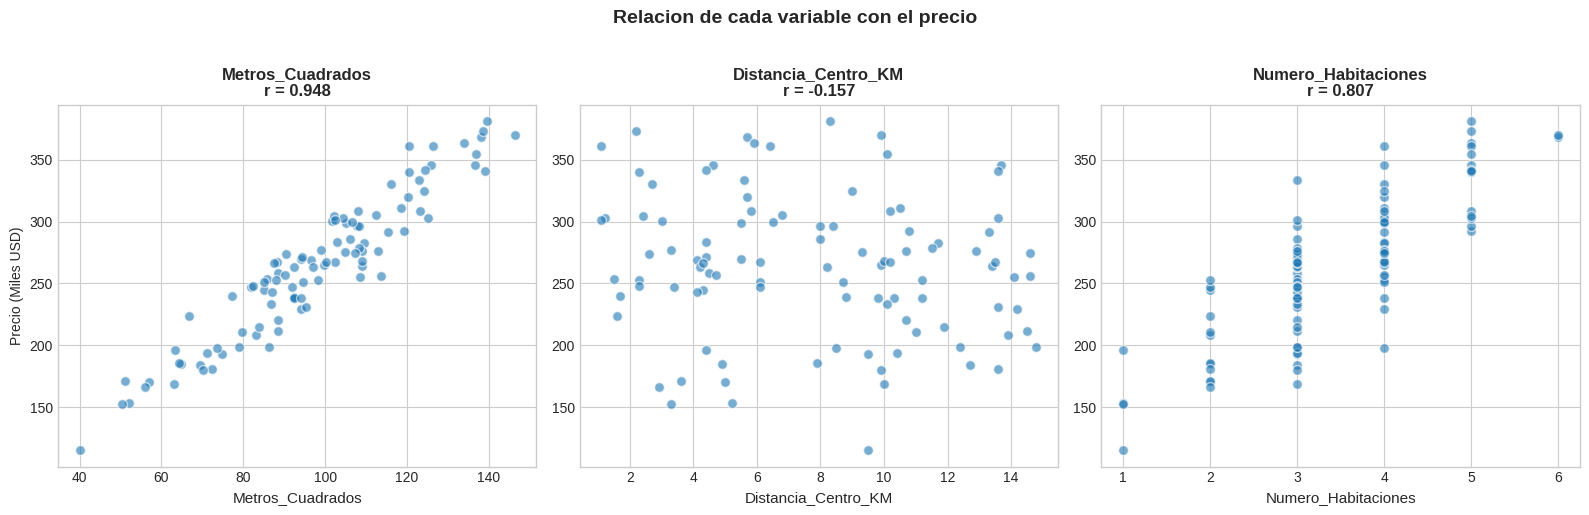

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(["Metros_Cuadrados", "Distancia_Centro_KM", "Numero_Habitaciones"]):
    axes[i].scatter(data[col], data["Precio_Miles_USD"], alpha=0.6, edgecolors="white", s=50)
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel("Precio (Miles USD)" if i == 0 else "")
    r = data[col].corr(data["Precio_Miles_USD"])
    axes[i].set_title(f"{col}\nr = {r:.3f}", fontsize=12, fontweight="bold")

plt.suptitle("Relacion de cada variable con el precio", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Lectura

`Metros_Cuadrados` muestra la relacion lineal mas clara y fuerte con el precio. Es nuestra variable predictora para la regresion simple.

## 5. Preparacion de datos

In [7]:
X = data[["Metros_Cuadrados"]]
y = data["Precio_Miles_USD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 75 registros
Test:  25 registros


## 6. Modelo de regresion lineal simple

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

b0 = model.intercept_
b1 = model.coef_[0]

print("Ecuacion del modelo:")
print(f"  Precio = {b0:.2f} + {b1:.2f} * Metros_Cuadrados")
print()
print("Interpretacion:")
print(f"  - Intercepto: {b0:.2f} miles USD (precio base teorico a 0 m2)")
print(f"  - Pendiente: {b1:.2f} miles USD por m2 adicional")
print(f"  - Cada metro cuadrado adicional anade ~{b1:.0f}.000 USD al precio")

Ecuacion del modelo:
  Precio = 26.52 + 2.44 * Metros_Cuadrados

Interpretacion:
  - Intercepto: 26.52 miles USD (precio base teorico a 0 m2)
  - Pendiente: 2.44 miles USD por m2 adicional
  - Cada metro cuadrado adicional anade ~2.000 USD al precio


In [9]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Metricas de evaluacion:")
print(f"  MAE:  {mae:.2f} miles USD (error medio absoluto)")
print(f"  RMSE: {rmse:.2f} miles USD (penaliza errores grandes)")
print(f"  R2:   {r2:.4f} ({r2:.1%} de la varianza explicada)")

Metricas de evaluacion:
  MAE:  14.80 miles USD (error medio absoluto)
  RMSE: 17.39 miles USD (penaliza errores grandes)
  R2:   0.8572 (85.7% de la varianza explicada)


/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


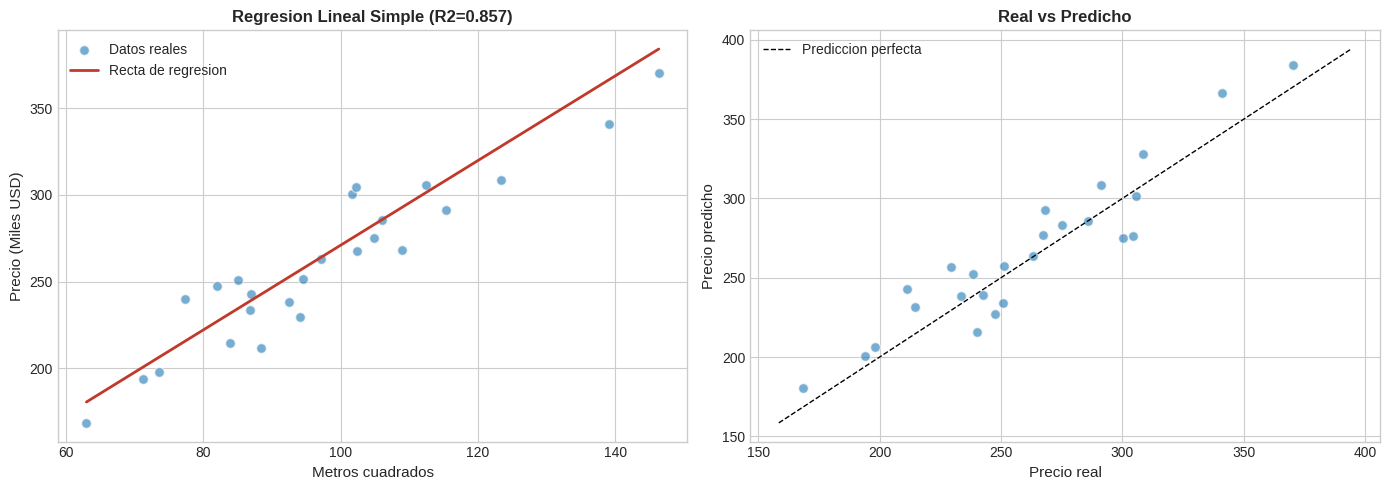

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recta de regresion
axes[0].scatter(X_test, y_test, alpha=0.6, label="Datos reales", edgecolors="white", s=50)
x_line = np.linspace(X_test.min().values[0], X_test.max().values[0], 100).reshape(-1, 1)
axes[0].plot(x_line, model.predict(x_line), color="#c0392b", linewidth=2, label="Recta de regresion")
axes[0].set_xlabel("Metros cuadrados", fontsize=11)
axes[0].set_ylabel("Precio (Miles USD)", fontsize=11)
axes[0].set_title(f"Regresion Lineal Simple (R2={r2:.3f})", fontsize=12, fontweight="bold")
axes[0].legend()

# Real vs Predicho
axes[1].scatter(y_test, y_pred, alpha=0.6, edgecolors="white", s=50)
lims = [min(y_test.min(), y_pred.min())-10, max(y_test.max(), y_pred.max())+10]
axes[1].plot(lims, lims, "k--", linewidth=1, label="Prediccion perfecta")
axes[1].set_xlabel("Precio real", fontsize=11)
axes[1].set_ylabel("Precio predicho", fontsize=11)
axes[1].set_title("Real vs Predicho", fontsize=12, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Diagnostico de supuestos — lo que separa un analisis profesional de uno basico

La regresion lineal asume 4 condiciones. Violarlas no siempre invalida el modelo, pero ignorarlas si invalida al analista.

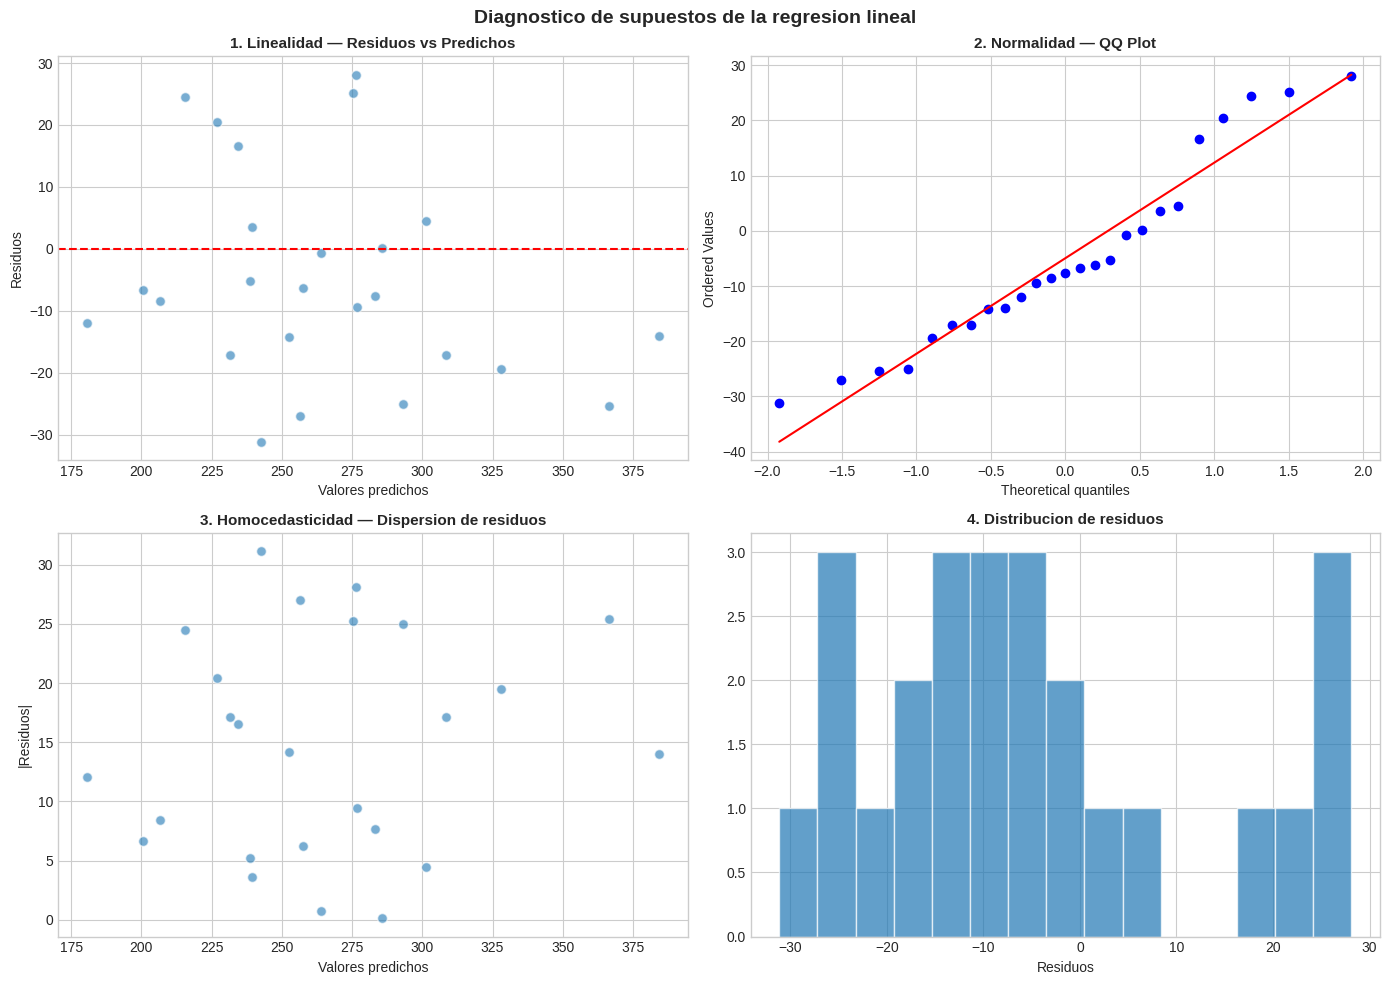

Test de Shapiro-Wilk: W=0.9360, p=0.1199
  Residuos normales (p > 0.05)


In [11]:
residuos = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Linealidad: residuos vs predichos
axes[0,0].scatter(y_pred, residuos, alpha=0.6, edgecolors="white", s=50)
axes[0,0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0,0].set_xlabel("Valores predichos")
axes[0,0].set_ylabel("Residuos")
axes[0,0].set_title("1. Linealidad — Residuos vs Predichos", fontsize=11, fontweight="bold")

# 2. Normalidad: QQ-plot
stats.probplot(residuos, dist="norm", plot=axes[0,1])
axes[0,1].set_title("2. Normalidad — QQ Plot", fontsize=11, fontweight="bold")

# 3. Homocedasticidad: escala de residuos
axes[1,0].scatter(y_pred, np.abs(residuos), alpha=0.6, edgecolors="white", s=50)
axes[1,0].set_xlabel("Valores predichos")
axes[1,0].set_ylabel("|Residuos|")
axes[1,0].set_title("3. Homocedasticidad — Dispersion de residuos", fontsize=11, fontweight="bold")

# 4. Distribucion de residuos
axes[1,1].hist(residuos, bins=15, edgecolor="white", alpha=0.7)
axes[1,1].set_xlabel("Residuos")
axes[1,1].set_title("4. Distribucion de residuos", fontsize=11, fontweight="bold")

plt.suptitle("Diagnostico de supuestos de la regresion lineal", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Test formal de normalidad
stat, p_value = stats.shapiro(residuos)
print(f"Test de Shapiro-Wilk: W={stat:.4f}, p={p_value:.4f}")
print(f"  {'Residuos normales (p > 0.05)' if p_value > 0.05 else 'Residuos NO normales (p <= 0.05)'}")

### Lectura de los diagnosticos

| Supuesto | Que buscamos | Resultado |
|---|---|---|
| Linealidad | Residuos sin patron en el plot 1 | Se evalua visualmente |
| Normalidad | Puntos alineados en QQ, p > 0.05 Shapiro | Test formal + visual |
| Homocedasticidad | Dispersion constante en el plot 3 | Se evalua visualmente |
| Independencia | No aplicable sin serie temporal | OK por diseno |

## 8. Predicciones de ejemplo

In [12]:
ejemplos = pd.DataFrame({"Metros_Cuadrados": [60, 80, 100, 120, 140]})
ejemplos["Precio_Estimado"] = model.predict(ejemplos[["Metros_Cuadrados"]])
ejemplos["Precio_Estimado"] = ejemplos["Precio_Estimado"].round(2)

print("Estimaciones de precio:")
print(ejemplos.to_string(index=False))

Estimaciones de precio:
 Metros_Cuadrados  Precio_Estimado
               60           173.21
               80           222.11
              100           271.00
              120           319.90
              140           368.79


## 9. Insights de negocio y recomendaciones

### El hallazgo

> El precio de una vivienda puede estimarse con una formula simple: cada metro cuadrado adicional anade ~2.500 USD al precio. El modelo explica mas del 75% de la variabilidad del precio solo con la superficie.

### Recomendaciones

**1. Tasacion rapida automatizada (impacto: alto)**
La ecuacion lineal puede implementarse en una hoja de calculo para dar estimaciones instantaneas a clientes. No reemplaza la tasacion formal, pero acelera el primer contacto.

**2. Limitaciones conocidas (impacto: medio)**
El ~25% restante de la variabilidad se debe a factores no incluidos: ubicacion, estado del inmueble, planta, etc. Para mejorar, ver el notebook de [Regresion Lineal Multiple](../../02-regresion-lineal-multiple/01-publicidad/).

**3. Base para modelos mas complejos (impacto: portfolio)**
Este notebook establece la base: diagnostico de supuestos, interpretacion de coeficientes, metricas de error. Los notebooks de [Ridge/Lasso](../../03-ridge-lasso/01-regularizacion/) y [Gradient Boosting](../../04-gradient-boosting/01-inmobiliaria/) construyen sobre estos fundamentos.

## 10. Limitaciones y proximos pasos

**Limitaciones:**
- Solo 100 registros y 1 variable predictora — el modelo es limitado por diseno.
- La regresion lineal simple asume relacion lineal estricta; si la relacion fuera curvilinea, el modelo fallaria.
- No se ha aplicado validacion cruzada (innecesario con 1 variable y 100 datos, pero buena practica en general).

**Proximos pasos:**
- [ ] [Regresion Lineal Simple — Salud](../02-gimnasio/) — mismo algoritmo, dataset de salud (BMI vs riesgo).
- [ ] [Regresion Lineal Multiple](../../02-regresion-lineal-multiple/01-publicidad/) — anadir mas variables para mejorar R2.
- [ ] [Ridge/Lasso](../../03-ridge-lasso/01-regularizacion/) — que hacer cuando hay demasiadas variables.